In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
# Makes graphs look clean in VS Code
%matplotlib inline

In [40]:
import pandas as pd
import numpy as np
train=pd.read_csv('C:/Users/rakes/Desktop/Rakesh/z/projects/house price prediction/train.csv')
test=pd.read_csv('C:/Users/rakes/Desktop/Rakesh/z/projects/house price prediction/test.csv')
print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Train shape: (1460, 81)
Test shape:  (1459, 80)


In [41]:
train.head()
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [42]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [43]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


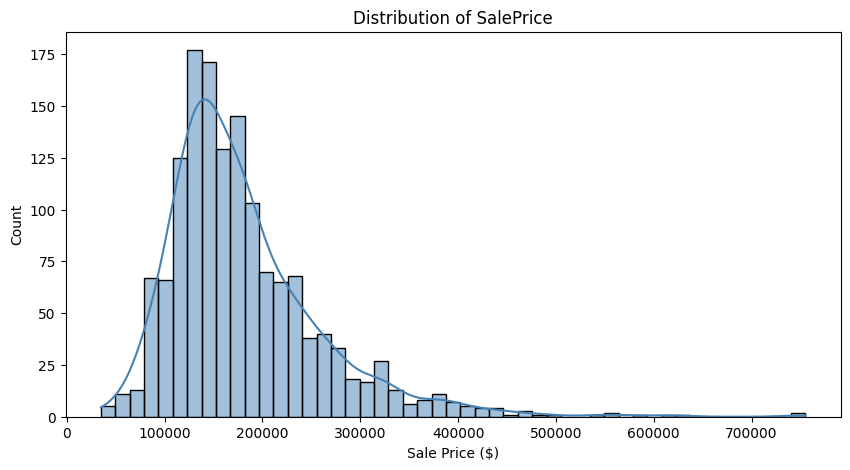

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(train['SalePrice'], kde=True, color='steelblue')
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.ylabel('Count')
plt.show()

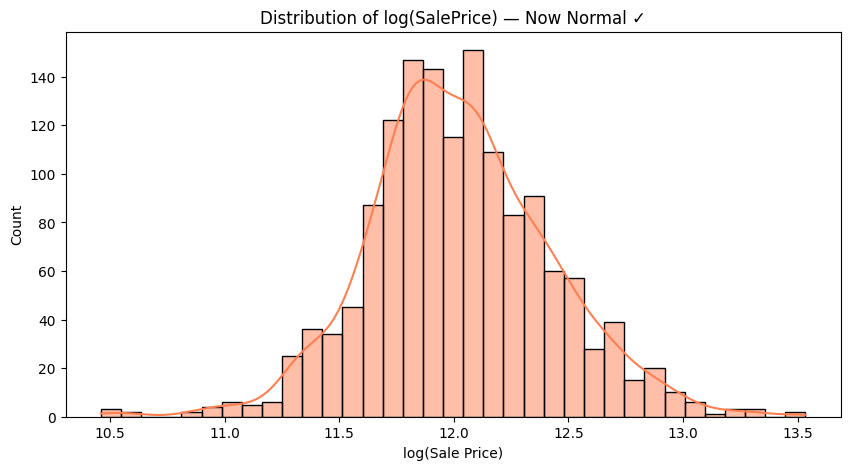

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train['SalePrice']), kde=True, color='coral')
plt.title('Distribution of log(SalePrice) — Now Normal ✓')
plt.xlabel('log(Sale Price)')
plt.ylabel('Count')
plt.show()

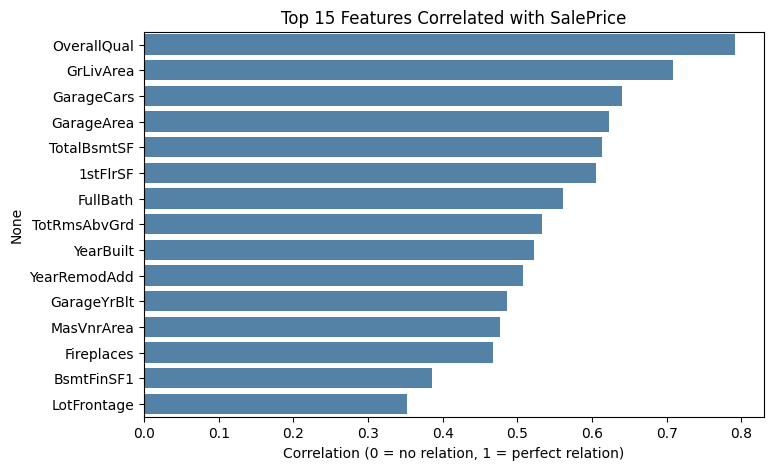

In [46]:
# Calculate correlation of every numeric column with SalePrice
correlation = train.select_dtypes(include=[np.number]).corr()

# Get top 15 features most correlated with SalePrice
top_corr = correlation['SalePrice'].abs().sort_values(ascending=False)[1:16]

plt.figure(figsize=(8, 5))
sns.barplot(x=top_corr.values, y=top_corr.index, color='steelblue')
plt.title('Top 15 Features Correlated with SalePrice')
plt.xlabel('Correlation (0 = no relation, 1 = perfect relation)')
plt.show()

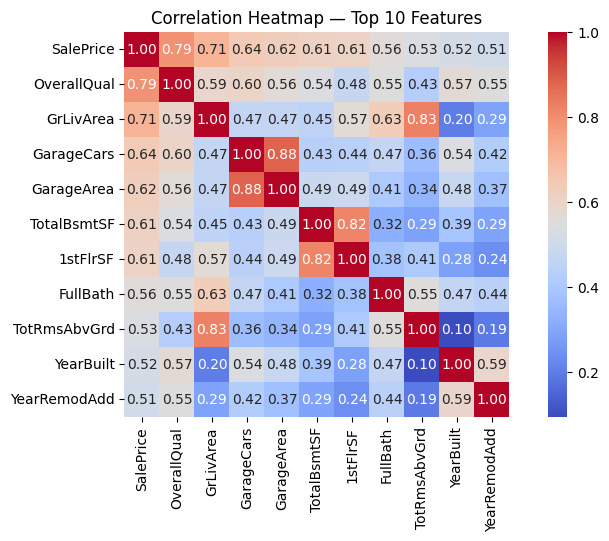

In [47]:
# Take only the top 10 correlated features
top_features = correlation['SalePrice'].abs().sort_values(ascending=False)[0:11].index

plt.figure(figsize=(10, 5))
sns.heatmap(
    train[top_features].corr(),
    annot=True,       # shows the numbers inside boxes
    fmt='.2f',        # 2 decimal places
    cmap='coolwarm',  # red = high, blue = low
    square=True
)
plt.title('Correlation Heatmap — Top 10 Features')
plt.show()

C:\Users\rakes\AppData\Local\Temp\ipykernel_21412\3020139294.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='Blues')


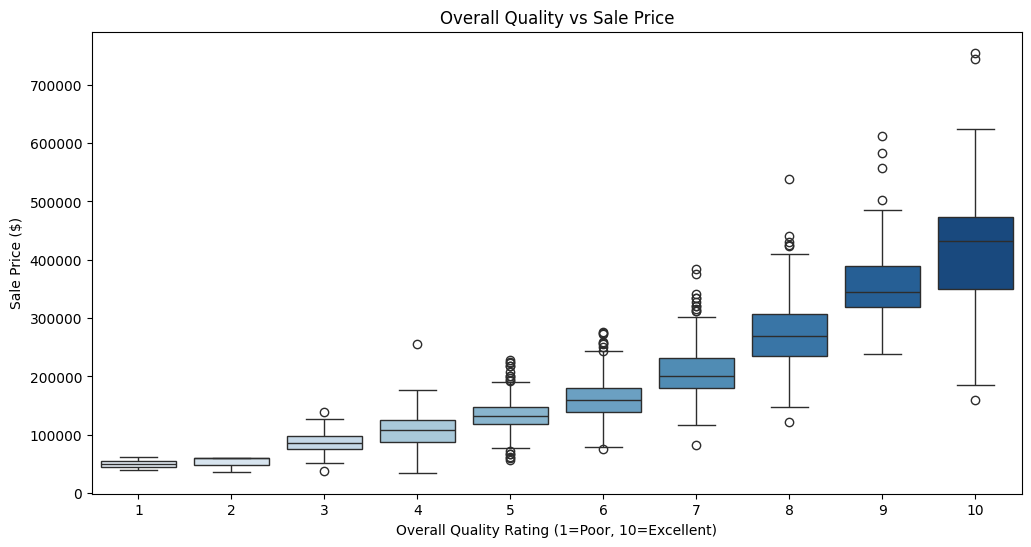

In [48]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='Blues')
plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality Rating (1=Poor, 10=Excellent)')
plt.ylabel('Sale Price ($)')
plt.show()

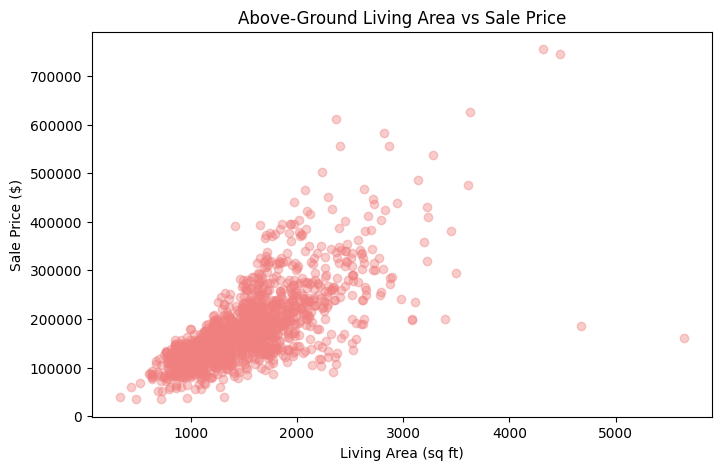

In [49]:
plt.figure(figsize=(8, 5))
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='lightcoral')
plt.title('Above-Ground Living Area vs Sale Price')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

C:\Users\rakes\AppData\Local\Temp\ipykernel_21412\1923137722.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


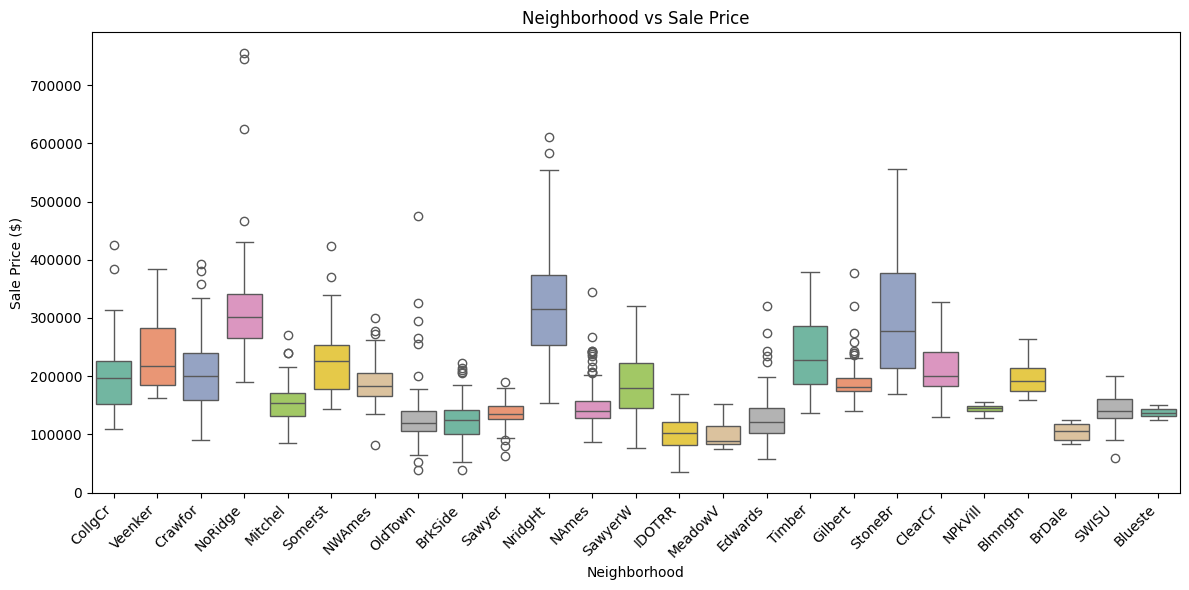

In [50]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=train,
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.title('Neighborhood vs Sale Price')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

In [51]:
# Before removal
print("Before:", train.shape)

# Remove houses with huge area but suspiciously low price
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

# Reset the index after dropping rows
train = train.reset_index(drop=True)

print("After:", train.shape)

Before: (1460, 81)
After: (1458, 81)


In [52]:
# GROUP 1 — Missing means "this feature doesn't exist"
# Example: PoolQC is missing because the house has NO pool
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    train[col] = train[col].fillna('None')

In [53]:
# GROUP 2 — Numeric columns where missing means 0
# Example: GarageArea is missing because there is no garage = 0 sqft
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    train[col] = train[col].fillna(0)

In [54]:
# GROUP 3 — LotFrontage: fill with median of same neighborhood
# Houses in the same neighborhood tend to have similar lot sizes
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [55]:
# GROUP 4 — Electrical has 1 missing — just fill with most common value
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [56]:
# CHECK — should print 0
print("Missing values remaining:", train.isnull().sum().sum())

Missing values remaining: 0


In [57]:
# Total square footage of the entire house
# This will become your #1 most important feature
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']

# Total number of bathrooms (half bath = 0.5)
train['TotalBaths'] = (train['FullBath'] + train['BsmtFullBath'] +
                       0.5 * (train['HalfBath'] + train['BsmtHalfBath']))

# Total porch area
train['TotalPorchSF'] = (train['OpenPorchSF'] + train['EnclosedPorch'] +
                          train['3SsnPorch'] + train['ScreenPorch'])

In [58]:
# How old is the house at the time of sale?
train['HouseAge'] = train['YrSold'] - train['YearBuilt']

# How many years since it was last remodeled?
train['YearsRemod'] = train['YrSold'] - train['YearRemodAdd']

# Was it ever remodeled at all? (1 = yes, 0 = no)
train['IsRemodeled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)

In [59]:
# Does it have a garage?
train['HasGarage'] = (train['GarageArea'] > 0).astype(int)

# Does it have a pool?
train['HasPool'] = (train['PoolArea'] > 0).astype(int)

# Does it have a fireplace?
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)

# Does it have any porch?
train['HasPorch'] = (train['TotalPorchSF'] > 0).astype(int)

In [60]:
# Quality × Size combined
# A high quality small house and a low quality big house
# can sell for the same price — this feature captures that nuance
train['QualXArea'] = train['OverallQual'] * train['TotalSF']

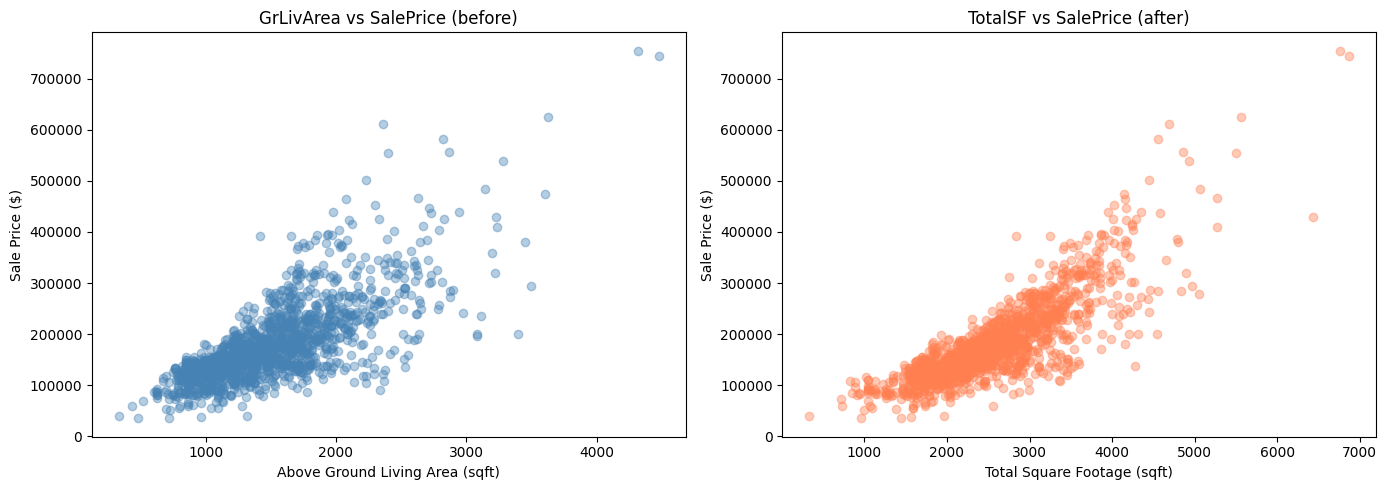

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Old way — just living area
axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')
axes[0].set_title('GrLivArea vs SalePrice (before)')
axes[0].set_xlabel('Above Ground Living Area (sqft)')
axes[0].set_ylabel('Sale Price ($)')

# New way — total SF including basement
axes[1].scatter(train['TotalSF'], train['SalePrice'], alpha=0.4, color='coral')
axes[1].set_title('TotalSF vs SalePrice (after)')
axes[1].set_xlabel('Total Square Footage (sqft)')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

In [62]:
# Check all new columns were created successfully
new_features = ['TotalSF', 'TotalBaths', 'TotalPorchSF',
                'HouseAge', 'YearsRemod', 'IsRemodeled',
                'HasGarage', 'HasPool', 'HasFireplace',
                'HasPorch', 'QualXArea']

print("New features created:", len(new_features))
print("\nSample values:")
print(train[new_features].head())

New features created: 11

Sample values:
   TotalSF  TotalBaths  TotalPorchSF  HouseAge  YearsRemod  IsRemodeled  \
0     2566         3.5            61         5           5            0   
1     2524         2.5             0        31          31            0   
2     2706         3.5            42         7           6            1   
3     2473         2.0           307        91          36            1   
4     3343         3.5            84         8           8            0   

   HasGarage  HasPool  HasFireplace  HasPorch  QualXArea  
0          1        0             0         1      17962  
1          1        0             1         0      15144  
2          1        0             1         1      18942  
3          1        0             1         1      17311  
4          1        0             1         1      26744  


In [63]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,TotalBaths,TotalPorchSF,HouseAge,YearsRemod,IsRemodeled,HasGarage,HasPool,HasFireplace,HasPorch,QualXArea
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,3.5,61,5,5,0,1,0,0,1,17962
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,2.5,0,31,31,0,1,0,1,0,15144
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,3.5,42,7,6,1,1,0,1,1,18942
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,2.0,307,91,36,1,1,0,1,1,17311
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,3.5,84,8,8,0,1,0,1,1,26744


In [64]:
# Map text quality ratings to numbers
quality_map = {
    'None': 0,  # doesn't exist
    'Po':   1,  # Poor
    'Fa':   2,  # Fair
    'TA':   3,  # Typical/Average
    'Gd':   4,  # Good
    'Ex':   5   # Excellent
}

# Columns that use this quality scale
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu',
                'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    train[col] = train[col].map(quality_map)

# Verify — should show numbers 0-5 now
print(train[['ExterQual', 'KitchenQual', 'FireplaceQu']].head(10))

   ExterQual  KitchenQual  FireplaceQu
0          4            4            0
1          3            3            3
2          4            4            3
3          3            4            4
4          4            4            3
5          3            3            0
6          4            4            4
7          3            3            3
8          3            3            3
9          3            3            3


In [65]:
# Before encoding
print("Columns before one-hot:", train.shape[1])

# One-hot encode all remaining text columns
# drop_first=True removes one column per category to avoid redundancy
train = pd.get_dummies(train, drop_first=True)

# After encoding
print("Columns after one-hot:", train.shape[1])

Columns before one-hot: 92
Columns after one-hot: 241


C:\Users\rakes\AppData\Local\Temp\ipykernel_21412\2651823478.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train['ExterQual'], y=train['SalePrice'], palette='Blues')


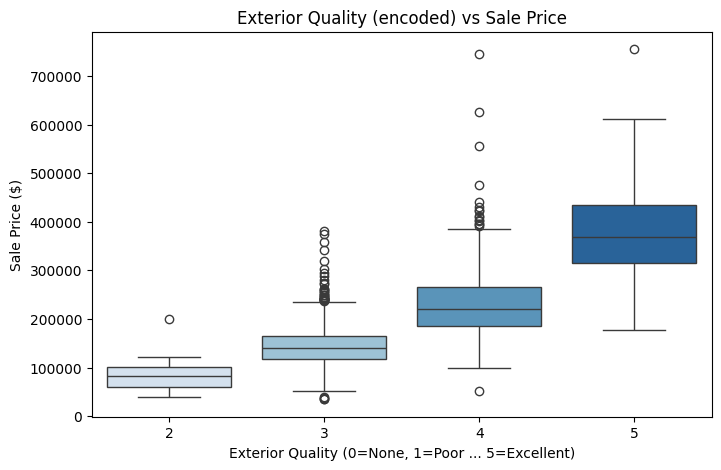

In [66]:
# After encoding, ExterQual should be numbers not text
plt.figure(figsize=(8, 5))
sns.boxplot(x=train['ExterQual'], y=train['SalePrice'], palette='Blues')
plt.title('Exterior Quality (encoded) vs Sale Price')
plt.xlabel('Exterior Quality (0=None, 1=Poor ... 5=Excellent)')
plt.ylabel('Sale Price ($)')
plt.show()

In [67]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = train.drop('SalePrice', axis=1)
y = np.log1p(train['SalePrice'])  # remember — we predict log(price)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFirst 5 target values (log scale):", y.head().values)

X shape: (1458, 240)
y shape: (1458,)

First 5 target values (log scale): [12.24769912 12.10901644 12.31717117 11.84940484 12.4292202 ]


In [68]:
# 80% for training, 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   # same number = same split every time you run
)

print("Training rows:  ", X_train.shape[0])
print("Validation rows:", X_val.shape[0])

Training rows:   1166
Validation rows: 292


In [69]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Train the model
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

# Predict on validation set
y_pred = ridge.predict(X_val)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2   = r2_score(y_val, y_pred)

print(f"Ridge Regression Results:")
print(f"RMSE : {rmse:.4f}  (in log scale)")
print(f"R²   : {r2:.3f}")

# Convert RMSE back to dollars to understand it
rmse_dollars = np.sqrt(mean_squared_error(
    np.expm1(y_val),
    np.expm1(y_pred)
))
print(f"RMSE : ${rmse_dollars:,.0f}  (in actual dollars)")

Ridge Regression Results:
RMSE : 0.1241  (in log scale)
R²   : 0.909
RMSE : $20,245  (in actual dollars)


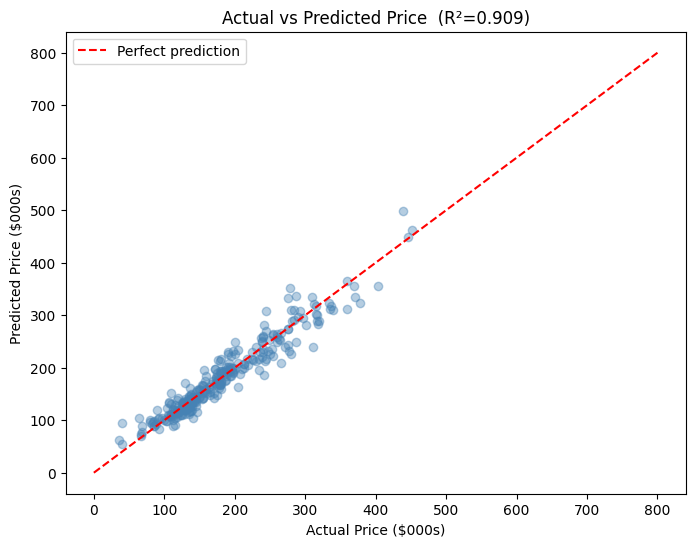

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_val)/1000,
            np.expm1(y_pred)/1000,
            alpha=0.4, color='steelblue')

# Perfect prediction line
plt.plot([0, 800], [0, 800], 'r--', lw=1.5, label='Perfect prediction')

plt.title(f'Actual vs Predicted Price  (R²={r2:.3f})')
plt.xlabel('Actual Price ($000s)')
plt.ylabel('Predicted Price ($000s)')
plt.legend()
plt.show()

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,    # number of trees
    max_depth=15,        # how deep each tree grows
    min_samples_leaf=2,  # minimum houses in each leaf
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf   = r2_score(y_val, y_pred_rf)

rmse_rf_dollars = np.sqrt(mean_squared_error(
    np.expm1(y_val), np.expm1(y_pred_rf)
))

print(f"Random Forest Results:")
print(f"RMSE : {rmse_rf:.4f}  (log scale)")
print(f"R²   : {r2_rf:.3f}")
print(f"RMSE : ${rmse_rf_dollars:,.0f}  (dollars)")

Random Forest Results:
RMSE : 0.1448  (log scale)
R²   : 0.876
RMSE : $24,635  (dollars)


In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gbm = GradientBoostingRegressor(
    n_estimators=500,    # number of trees built sequentially
    learning_rate=0.05,  # how much each tree corrects the previous
    max_depth=4,         # shallower trees work better here
    random_state=42
)

gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_val)

rmse_gbm = np.sqrt(mean_squared_error(y_val, y_pred_gbm))
r2_gbm   = r2_score(y_val, y_pred_gbm)

rmse_gbm_dollars = np.sqrt(mean_squared_error(
    np.expm1(y_val), np.expm1(y_pred_gbm)
))

print(f"Gradient Boosting Results:")
print(f"RMSE : {rmse_gbm:.4f}  (log scale)")
print(f"R²   : {r2_gbm:.3f}")
print(f"RMSE : ${rmse_gbm_dollars:,.0f}  (dollars)")

Gradient Boosting Results:
RMSE : 0.1330  (log scale)
R²   : 0.895
RMSE : $21,530  (dollars)


In [73]:
results = {
    'Ridge Regression': {'R2': r2,      'RMSE_$': 20245},
    'Random Forest':    {'R2': r2_rf,   'RMSE_$': rmse_rf_dollars},
    'Gradient Boosting':{'R2': r2_gbm,  'RMSE_$': rmse_gbm_dollars},
}

print(f"{'Model':<25} {'R²':>8} {'RMSE ($)':>12}")
print("-" * 47)
for model, scores in results.items():
    print(f"{model:<25} {scores['R2']:>8.3f} ${scores['RMSE_$']:>10,.0f}")

Model                           R²     RMSE ($)
-----------------------------------------------
Ridge Regression             0.909 $    20,245
Random Forest                0.876 $    24,635
Gradient Boosting            0.895 $    21,530


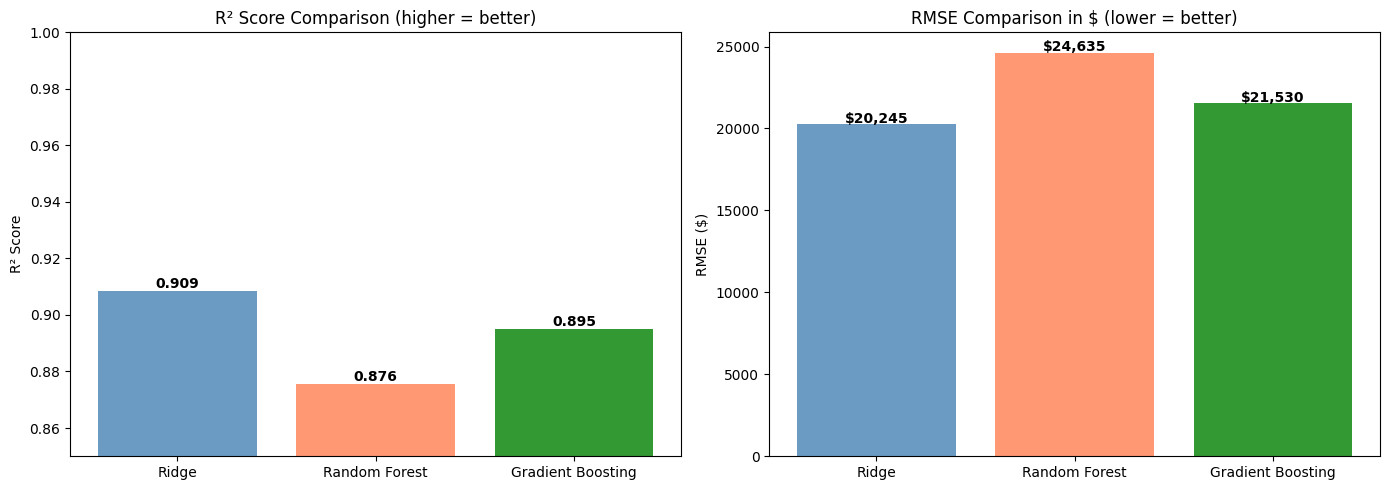

In [74]:
models      = ['Ridge', 'Random Forest', 'Gradient Boosting']
r2_scores   = [r2, r2_rf, r2_gbm]
rmse_scores = [20245, rmse_rf_dollars, rmse_gbm_dollars]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison — higher is better
axes[0].bar(models, r2_scores, color=['steelblue', 'coral', 'green'], alpha=0.8)
axes[0].set_title('R² Score Comparison (higher = better)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0.85, 1.0)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

# RMSE comparison — lower is better
axes[1].bar(models, rmse_scores, color=['steelblue', 'coral', 'green'], alpha=0.8)
axes[1].set_title('RMSE Comparison in $ (lower = better)')
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 100, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\rakes\AppData\Local\Temp\ipykernel_21412\4078213217.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


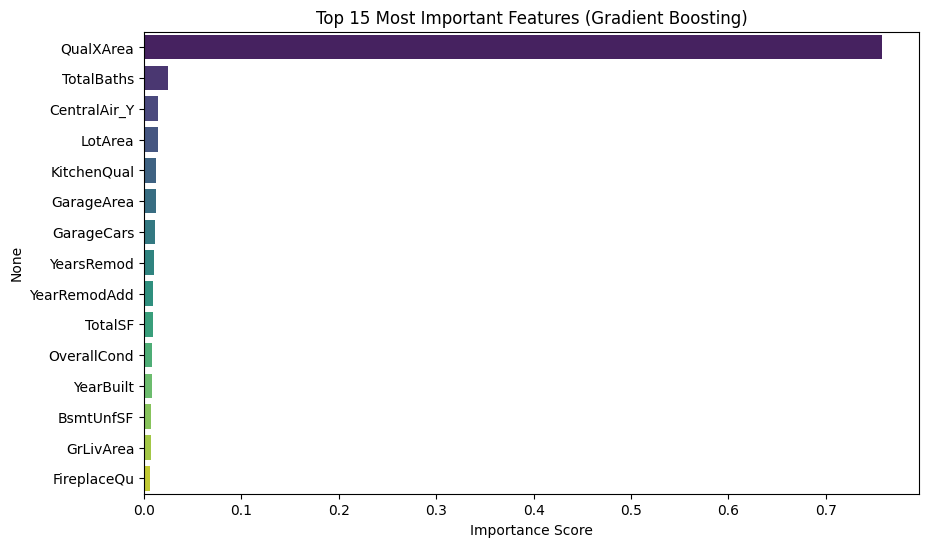

In [75]:
# Get feature importances from Gradient Boosting
feat_imp = pd.Series(
    gbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Top 15 Most Important Features (Gradient Boosting)')
plt.xlabel('Importance Score')
plt.show()

In [76]:
from sklearn.model_selection import KFold, cross_val_score

# 5-Fold Cross Validation
# Splits your training data into 5 parts
# Trains 5 times, each time using a different part as validation
# Gives you a more reliable score than a single train/val split

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model):
    scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        n_jobs=-1
    )
    return -scores.mean(), scores.std()

# Check your current models with cross validation
ridge_mean, ridge_std = rmse_cv(Ridge(alpha=10))
gbm_mean,   gbm_std   = rmse_cv(gbm)

print(f"Ridge  CV RMSE: {ridge_mean:.4f} ± {ridge_std:.4f}")
print(f"GBM    CV RMSE: {gbm_mean:.4f} ± {gbm_std:.4f}")

Ridge  CV RMSE: 0.1138 ± 0.0094
GBM    CV RMSE: 0.1226 ± 0.0118


In [77]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the search space — ranges to try
param_dist = {
    'n_estimators':     randint(200, 1000),
    'learning_rate':    uniform(0.01, 0.2),
    'max_depth':        randint(2, 7),
    'min_samples_leaf': randint(1, 15),
    'subsample':        uniform(0.6, 0.4),
    'max_features':     uniform(0.5, 0.5),
}

# This will try 50 random combinations
# Each combination tested with 5-fold CV
# Total = 50 × 5 = 250 model trainings
random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Tuning started — this will take 3-5 minutes...")
random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest CV RMSE: {-random_search.best_score_:.4f}")

Tuning started — this will take 3-5 minutes...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters Found:
{'learning_rate': np.float64(0.050343840467079244), 'max_depth': 2, 'max_features': np.float64(0.6571779905381634), 'min_samples_leaf': 4, 'n_estimators': 933, 'subsample': np.float64(0.6557325817623503)}

Best CV RMSE: 0.1157


In [78]:
# Get the best model from the search
best_model = random_search.best_estimator_

# Predict on validation set
y_pred_tuned = best_model.predict(X_val)

rmse_tuned = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
r2_tuned   = r2_score(y_val, y_pred_tuned)
rmse_tuned_dollars = np.sqrt(mean_squared_error(
    np.expm1(y_val), np.expm1(y_pred_tuned)
))

print(f"Tuned Gradient Boosting Results:")
print(f"R²   : {r2_tuned:.3f}")
print(f"RMSE : ${rmse_tuned_dollars:,.0f}")

# Compare before vs after tuning
print(f"\nBefore tuning RMSE: $21,530")
print(f"After  tuning RMSE: ${rmse_tuned_dollars:,.0f}")
print(f"Improvement: ${21530 - rmse_tuned_dollars:,.0f}")

Tuned Gradient Boosting Results:
R²   : 0.910
RMSE : $20,229

Before tuning RMSE: $21,530
After  tuning RMSE: $20,229
Improvement: $1,301


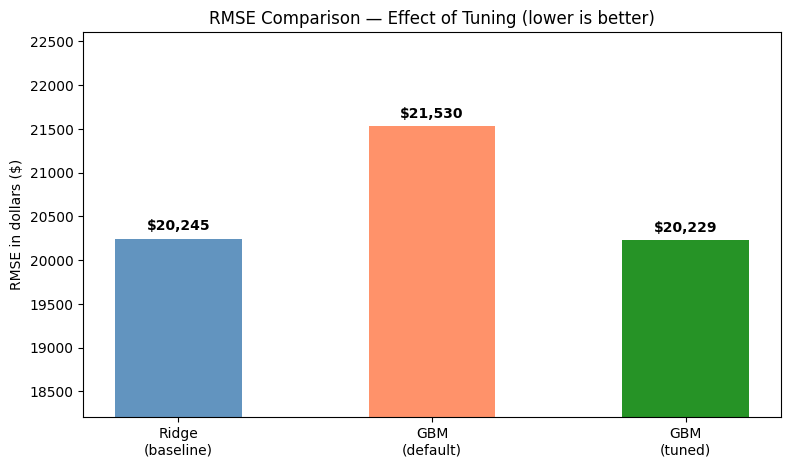

In [79]:
models_compare  = ['Ridge\n(baseline)', 'GBM\n(default)', 'GBM\n(tuned)']
rmse_compare    = [20245, 21530, rmse_tuned_dollars]
colors          = ['steelblue', 'coral', 'green']

plt.figure(figsize=(9, 5))
bars = plt.bar(models_compare, rmse_compare, color=colors, alpha=0.85, width=0.5)
plt.title('RMSE Comparison — Effect of Tuning (lower is better)')
plt.ylabel('RMSE in dollars ($)')
plt.ylim(min(rmse_compare) * 0.9, max(rmse_compare) * 1.05)

for bar, val in zip(bars, rmse_compare):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 100, f'${val:,.0f}',
             ha='center', fontweight='bold')
plt.show()

In [80]:
# Calculate residuals
y_actual    = np.expm1(y_val)
y_predicted = np.expm1(y_pred_tuned)
residuals   = y_actual - y_predicted

print(f"Mean residual  : ${residuals.mean():,.0f}   (should be near $0)")
print(f"Std of residuals: ${residuals.std():,.0f}")

Mean residual  : $-692   (should be near $0)
Std of residuals: $20,252


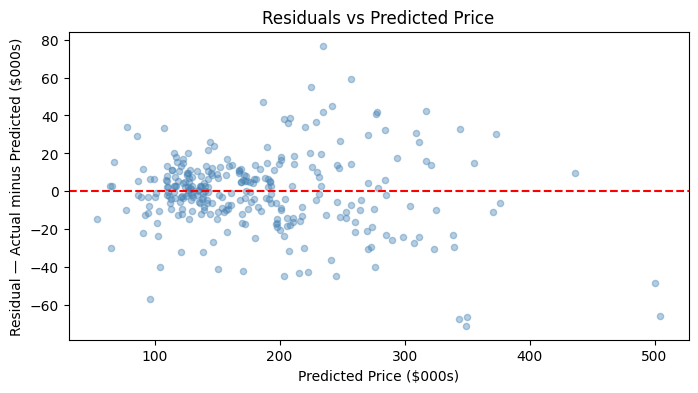

In [81]:
plt.figure(figsize=(8, 4))
plt.scatter(y_predicted/1000, residuals/1000,
            alpha=0.4, color='steelblue', s=20)
plt.axhline(y=0, color='red', linestyle='--', lw=1.5)
plt.title('Residuals vs Predicted Price')
plt.xlabel('Predicted Price ($000s)')
plt.ylabel('Residual — Actual minus Predicted ($000s)')
plt.show()

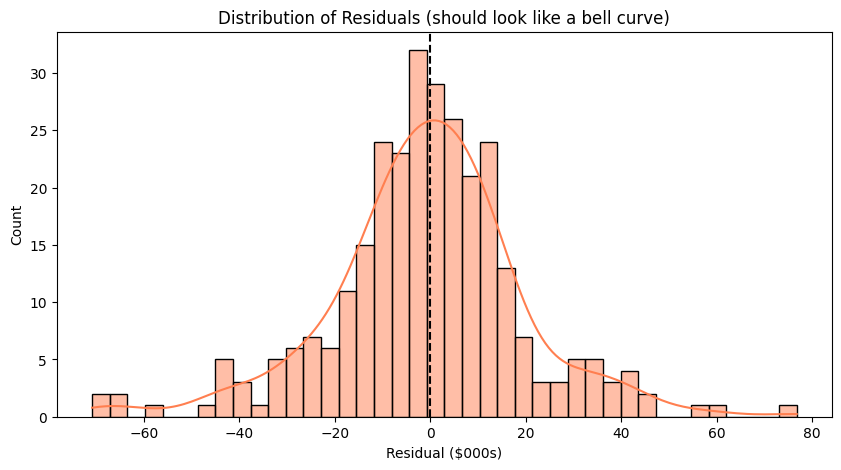

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(residuals/1000, kde=True, color='coral', bins=40)
plt.axvline(x=0, color='black', linestyle='--', lw=1.5)
plt.title('Distribution of Residuals (should look like a bell curve)')
plt.xlabel('Residual ($000s)')
plt.ylabel('Count')
plt.show()

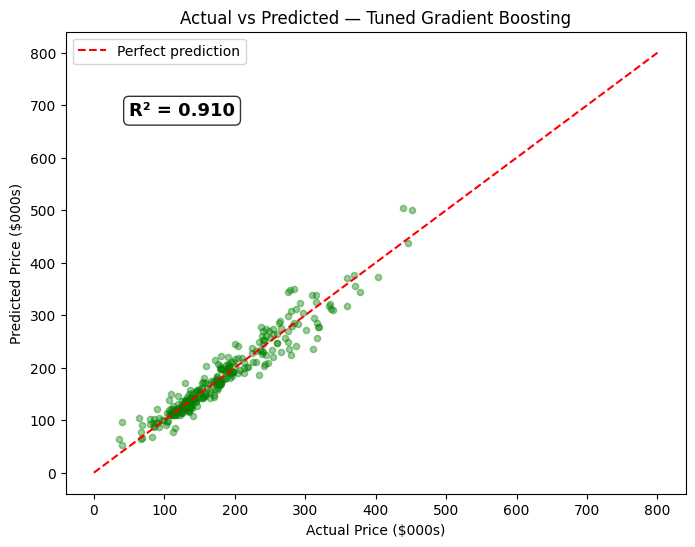

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(y_actual/1000, y_predicted/1000,
            alpha=0.4, color='green', s=20)
plt.plot([0, 800], [0, 800], 'r--', lw=1.5, label='Perfect prediction')

# Add R² to the chart
plt.text(50, 680, f'R² = {r2_tuned:.3f}', fontsize=13, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Actual vs Predicted — Tuned Gradient Boosting')
plt.xlabel('Actual Price ($000s)')
plt.ylabel('Predicted Price ($000s)')
plt.legend()
plt.show()

In [84]:
# Calculate MAPE — Mean Absolute Percentage Error
mape = np.mean(np.abs(residuals / y_actual)) * 100

print("=" * 40)
print("   FINAL MODEL SCORECARD")
print("=" * 40)
print(f"  Model    : Tuned Gradient Boosting")
print(f"  R²       : {r2_tuned:.3f}")
print(f"  RMSE     : ${rmse_tuned_dollars:,.0f}")
print(f"  MAE      : ${np.mean(np.abs(residuals)):,.0f}")
print(f"  MAPE     : {mape:.1f}%")
print(f"  CV RMSE  : 0.1157")
print("=" * 40)

   FINAL MODEL SCORECARD
  Model    : Tuned Gradient Boosting
  R²       : 0.910
  RMSE     : $20,229
  MAE      : $14,600
  MAPE     : 8.8%
  CV RMSE  : 0.1157


In [85]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Fit on FULL training data before saving
# (not just the 80% split — use everything)
best_model.fit(X_train, y_train)

# Save model and feature names
joblib.dump(best_model,              'models/house_price_model.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')

print("Model saved successfully!")
print("File size:", os.path.getsize('models/house_price_model.pkl') // 1024, "KB")

# Test loading works
loaded_model    = joblib.load('models/house_price_model.pkl')
loaded_features = joblib.load('models/feature_names.pkl')
print("Model loaded back successfully!")
print("Number of features:", len(loaded_features))

Model saved successfully!
File size: 969 KB
Model loaded back successfully!
Number of features: 240


In [86]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save the tuned model
joblib.dump(best_model, 'models/house_price_model.pkl')

# Save feature names — app needs exact same columns as training
joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')

print("Saved! Files in models/ folder:")
print(os.listdir('models'))

Saved! Files in models/ folder:
['feature_names.pkl', 'house_price_model.pkl']
